In [28]:
import pathlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [29]:
print(tf.__version__)

2.20.0


In [30]:
# ucitavanje podataka
dataset_path = keras.utils.get_file("auto-mpg.data", "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")
dataset_path

'/root/.keras/datasets/auto-mpg.data'

In [31]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
raw_dataset = pd.read_csv(dataset_path, names = column_names, na_values = "?", comment = '\t', sep = " ", skipinitialspace = True)

In [32]:
dataset = raw_dataset.copy()
dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [33]:
# sredjivanje podataka
dataset.isna().sum() # set sadrzi nedostajuce vrednosti

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model Year,0
Origin,0


In [34]:
dataset = dataset.dropna() # samo cemo ih izbaciti
dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,0
Weight,0
Acceleration,0
Model Year,0
Origin,0


In [35]:
# enkodiranje kategorickih promenljivih
print(dataset.Origin.unique())

[1 3 2]


In [36]:
# JAKO KORISNO: menjamo vrednosti neke kolone uz pomoc prosledjene mape
# dataset['Origin'] = dataset['Origin'].map({1 : 'USA', 2 : 'Europe', 3 : 'Japan'})

# dummy enkodiranje je isto sto i one hot enkodiranje
# dataset = pd.get_dummies(dataset, prefix = '', prefix_sep = '') -> sad ne radimo jer prilikom normalizacije dobijamo nan vrednsoti sto zatim prouzrokuje da model kao rezultat vraca nan vrednosti takodje
# dataset

In [38]:
# podela podataka
train_dataset = dataset.sample(frac = 0.8, random_state = 0)
test_dataset = dataset.drop(train_dataset.index)

In [39]:
train_dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
146,28.0,4,90.0,75.0,2125.0,14.5,74,1
282,22.3,4,140.0,88.0,2890.0,17.3,79,1
69,12.0,8,350.0,160.0,4456.0,13.5,72,1
378,38.0,4,105.0,63.0,2125.0,14.7,82,1
331,33.8,4,97.0,67.0,2145.0,18.0,80,3
...,...,...,...,...,...,...,...,...
281,19.8,6,200.0,85.0,2990.0,18.2,79,1
229,16.0,8,400.0,180.0,4220.0,11.1,77,1
150,26.0,4,108.0,93.0,2391.0,15.5,74,3
145,32.0,4,83.0,61.0,2003.0,19.0,74,3


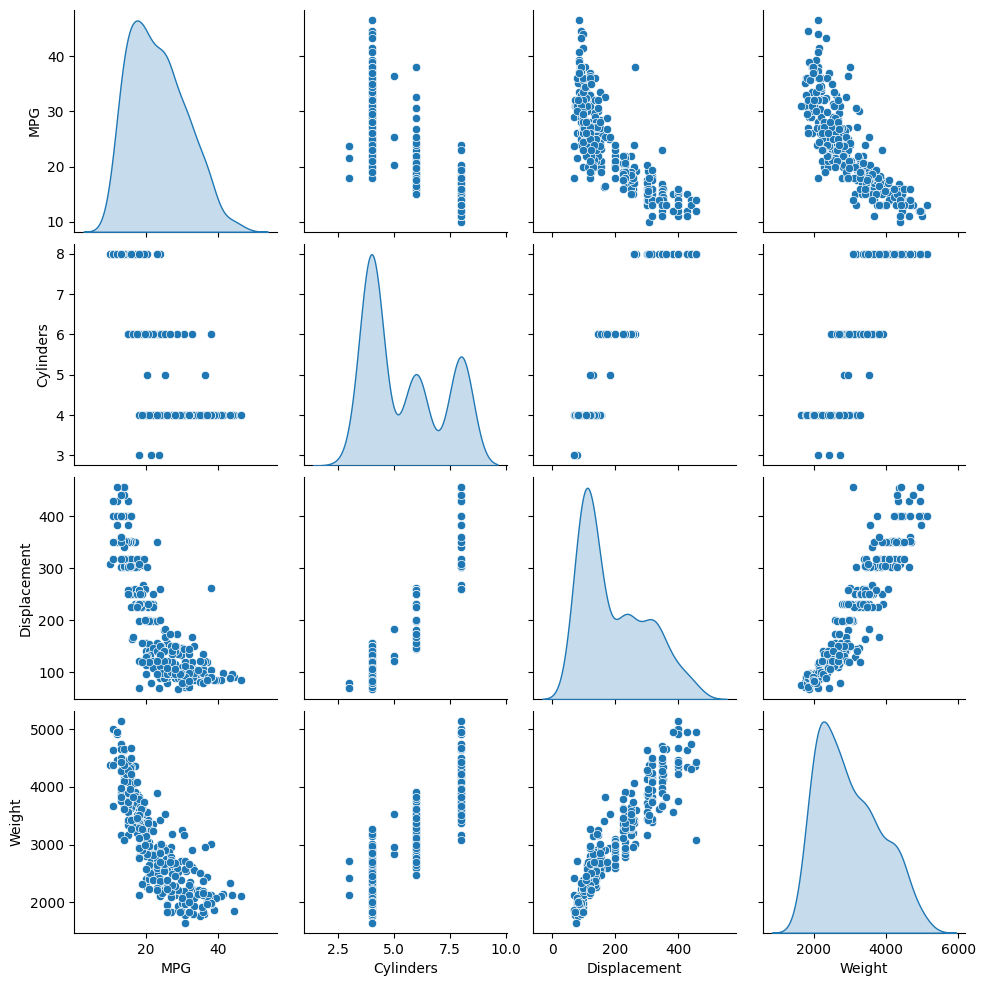

In [40]:
# analiza podataka

# medjusobno poredjenje atributa u podacima
sns.pairplot(train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind = "kde")

In [41]:
# opste statistike (ignorisemo MPG jer ce nam ona biti ciljna promenljiva)

train_stats = train_dataset.describe()
train_stats.pop("MPG")
train_stats = train_stats.transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
Origin,314.0,1.573248,0.800988,1.0,1.00,1.0,2.00,3.0


In [42]:
# izdvajamo ciljnu promenljivu
train_labels = train_dataset.pop('MPG')
test_labels = test_dataset.pop('MPG')

In [43]:
train_labels

,MPG
146,28.0
282,22.3
69,12.0
378,38.0
331,33.8
...,...
281,19.8
229,16.0
150,26.0
145,32.0


In [44]:
# standardizacija
def norm(x):
  return (x - train_stats['mean']) / train_stats['std']

In [45]:
normed_train_dataset = norm(train_dataset)
normed_test_dataset = norm(test_dataset)

In [46]:
normed_train_dataset

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
146,-0.869348,-1.009459,-0.784052,-1.025303,-0.379759,-0.516397,-0.715676
282,-0.869348,-0.530218,-0.442811,-0.118796,0.624102,0.843910,-0.715676
69,1.483887,1.482595,1.447140,1.736877,-0.738281,-1.060519,-0.715676
378,-0.869348,-0.865687,-1.099044,-1.025303,-0.308055,1.660094,-0.715676
331,-0.869348,-0.942365,-0.994047,-1.001603,0.875068,1.115971,1.781239
...,...,...,...,...,...,...,...
281,0.307270,0.044872,-0.521559,-0.000298,0.946772,0.843910,-0.715676
229,1.483887,1.961837,1.972127,1.457223,-1.598734,0.299787,-0.715676
150,-0.869348,-0.836932,-0.311564,-0.710099,-0.021237,-0.516397,1.781239
145,-0.869348,-1.076553,-1.151543,-1.169870,1.233589,-0.516397,1.781239


In [47]:
normed_train_dataset.describe()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,3.140000e+02,3.140000e+02,3.140000e+02,3.140000e+02,3.140000e+02,3.140000e+02,3.140000e+02
mean,1.725442e-16,8.344351e-17,-1.131437e-17,-8.485781e-17,-5.148041e-16,9.461646e-16,-9.900078e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.457657e+00,-1.220325e+00,-1.545283e+00,-1.589352e+00,-2.710152e+00,-1.604642e+00,-7.156763e-01
25%,-8.693480e-01,-8.608943e-01,-7.512407e-01,-8.694784e-01,-6.307245e-01,-7.884578e-01,-7.156763e-01
50%,-8.693480e-01,-4.247848e-01,-2.721905e-01,-1.987817e-01,-2.123729e-02,2.772599e-02,-7.156763e-01
75%,1.483887e+00,6.750739e-01,6.071620e-01,7.320173e-01,5.882500e-01,8.439098e-01,5.327813e-01
max,1.483887e+00,2.489002e+00,3.153347e+00,2.547401e+00,3.313017e+00,1.660094e+00,1.781239e+00


In [48]:
# regresioni model
model = keras.Sequential([
    layers.Dense(64, activation = 'relu', input_shape = [len(train_dataset.keys())]),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(1)
])

model.compile(optimizer = tf.keras.optimizers.RMSprop(0.001), loss = 'mse', metrics = ['mae', 'mse'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
# pregled definisanog modela
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# obucavanje modela
history = model.fit(normed_train_dataset, train_labels, epochs = 1000, validation_split = 0.2, verbose = 1)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6.4951 - mae: 1.7814 - mse: 6.4951 - val_loss: 9.2113 - val_mae: 2.3258 - val_mse: 9.2113
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 6.6309 - mae: 1.8190 - mse: 6.6309 - val_loss: 9.2575 - val_mae: 2.3606 - val_mse: 9.2575
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.4857 - mae: 1.7803 - mse: 6.4857 - val_loss: 9.2144 - val_mae: 2.2991 - val_mse: 9.2144
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3749 - mae: 1.7642 - mse: 6.3749 - val_loss: 9.6584 - val_mae: 2.4217 - val_mse: 9.6584
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4536 - mae: 1.7764 - mse: 6.4536 - val_loss: 9.2232 - val_mae: 2.2970 - val_mse: 9.2232
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.2992 - mae: 1.7751 - mse: 6.2992 - val_loss: 9.1428 - val_mae: 2.3162 - val_mse: 9.1428
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.2548 - mae: 1.7191 - mse: 6.2548 - val_loss: 

In [58]:
example_batch = normed_train_dataset[:10]
example_result = model.predict(example_batch)
example_result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[28.313213],
       [23.757765],
       [12.398148],
       [37.933407],
       [36.37795 ],
       [20.5442  ],
       [38.97238 ],
       [30.937542],
       [20.495005],
       [21.737099]], dtype=float32)

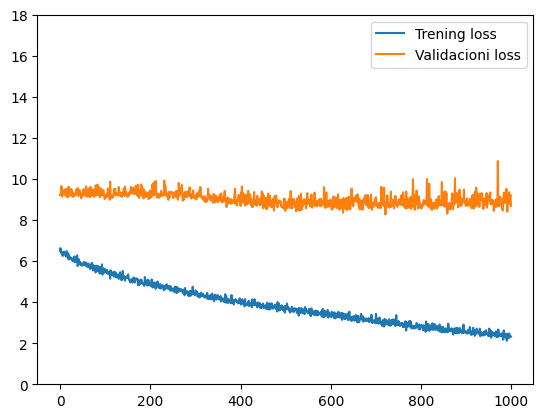

In [64]:
plt.plot(history.epoch, history.history['loss'])
plt.plot(history.epoch, history.history['val_loss'])
plt.ylim([0, 18])
plt.legend(['Trening loss', 'Validacioni loss'])

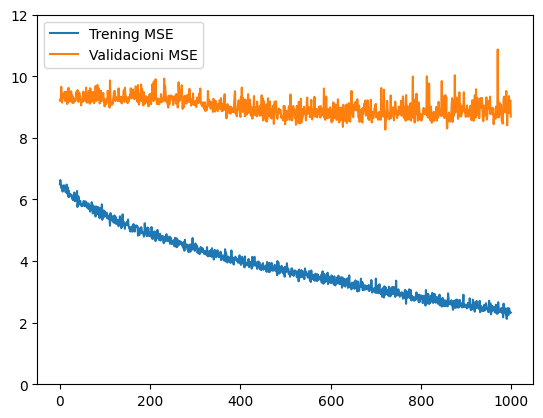

In [59]:
plt.plot(history.epoch, history.history['mse'])
plt.plot(history.epoch, history.history['val_mse'])
plt.ylim([0, 12])
plt.legend(['Trening MSE', 'Validacioni MSE'])

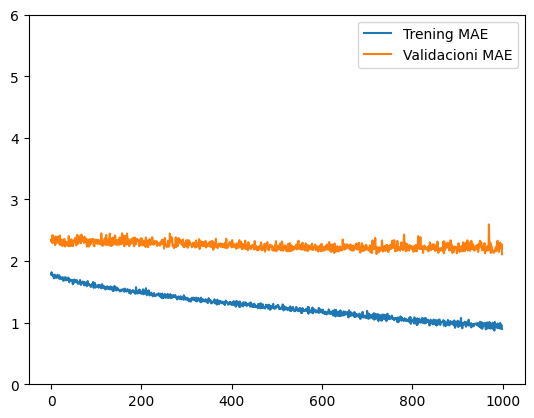

In [60]:
plt.plot(history.epoch, history.history['mae'])
plt.plot(history.epoch, history.history['val_mae'])
plt.ylim([0, 6])
plt.legend(['Trening MAE', 'Validacioni MAE'])

In [61]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
995,2.470408,0.995017,2.470408,9.356094,2.298995,9.356094,995
996,2.420892,0.907738,2.420892,8.803660,2.231031,8.803660,996
997,2.326158,0.962182,2.326158,9.107597,2.203160,9.107597,997
998,2.341545,0.959731,2.341545,9.217335,2.272497,9.217335,998
999,2.325033,0.898680,2.325033,8.690816,2.110306,8.690816,999


In [65]:
# primecujemo da 1000 epoha ne doprinosi poboljsanju modela, pa cemo sada iskoristiti early stoping tehniku optimizacije (tehnika ranog zaustavljanja)
# ideja je definisati skup ogranicenja i treniranje modela se obustavlja kada se ova ogranicenja dostignu

model1 = keras.Sequential([
    layers.Dense(64, activation = 'relu', input_shape = [len(train_dataset.keys())]),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(1)
])
model1.compile(optimizer = tf.keras.optimizers.RMSprop(0.001), loss = 'mse', metrics = ['mae', 'mse'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
history1 = model1.fit(normed_train_dataset, train_labels, epochs = 1000, validation_split = 0.2, verbose = 1, callbacks = [keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 10)])

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 557.6006 - mae: 22.3760 - mse: 557.6006 - val_loss: 547.6721 - val_mae: 22.1050 - val_mse: 547.6721
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 507.5918 - mae: 21.2273 - mse: 507.5918 - val_loss: 498.6974 - val_mae: 20.9619 - val_mse: 498.6974
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 460.6435 - mae: 20.1119 - mse: 460.6435 - val_loss: 445.0382 - val_mae: 19.6590 - val_mse: 445.0382
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 409.6985 - mae: 18.8518 - mse: 409.6985 - val_loss: 388.2174 - val_mae: 18.2012 - val_mse: 388.2174
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 356.5815 - mae: 17.4271 - mse: 356.5815 - val_loss: 329.7043 - val_mae: 16.5615 - val_mse: 329.7043
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 302.5210 - mae: 15.8543 - mse: 302.5210 - val_loss: 272.0926 - val_mae: 14.8239 - val_mse: 272.0926
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/

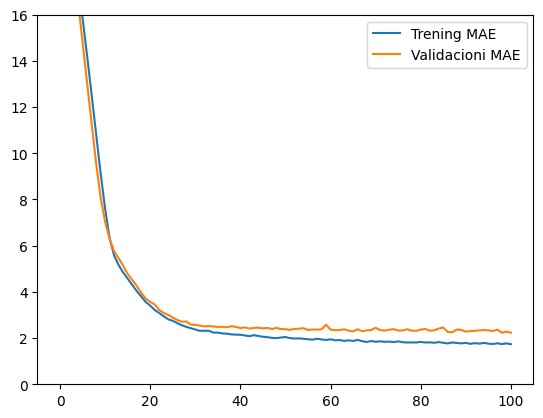

In [68]:
plt.plot(history1.epoch, history1.history['mae'])
plt.plot(history1.epoch, history1.history['val_mae'])
plt.ylim([0, 16])
plt.legend(['Trening MAE', 'Validacioni MAE'])

In [69]:
# evaluacija modela
# procenjujemo kakva je generalizacija modela na skupu za testiranje

model2 = keras.Sequential([
    layers.Dense(64, activation = 'relu', input_shape = [len(train_dataset.keys())]),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(1)
])
model2.compile(optimizer = tf.keras.optimizers.RMSprop(0.001), loss = 'mse', metrics = ['mae', 'mse'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
history2 = model2.fit(normed_train_dataset, train_labels, epochs = 100, verbose = 1)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 562.2936 - mae: 22.4358 - mse: 562.2936  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 504.2377 - mae: 21.0947 - mse: 504.2377 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 439.4666 - mae: 19.5103 - mse: 439.4666 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 366.8705 - mae: 17.5512 - mse: 366.8705 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 289.0595 - mae: 15.2993 - mse: 289.0595 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 214.9573 - mae: 12.9659 - mse: 214.9573 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 150.2775 - mae: 10.7062 - mse: 150.2775 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 98.8758 - mae: 8.5283 - mse: 98.8758 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 65.3018 - mae: 6.7017 - mse: 65.3018 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.5666 - mae: 5.5735 - mse: 46.5666 
Epoch 1

In [72]:
loss, mae, mse = model2.evaluate(normed_test_dataset, test_labels, verbose = 2)

print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))

3/3 - 0s - 74ms/step - loss: 6.5669 - mae: 1.8810 - mse: 6.5669
Testing set Mean Abs Error:  1.88 MPG
